# NRRD File Viewer
This notebook demonstrates how to read and visualize NRRD files (volumes and segmentations)


## 1. Install Required Libraries
Run this cell first if you haven't installed these packages yet


In [1]:
# Uncomment and run if needed
# !pip install pynrrd matplotlib numpy pandas ipywidgets


## 2. Import Libraries


In [2]:
import nrrd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# Set up matplotlib for better visualization
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['image.cmap'] = 'gray'


## 3. Read an NRRD File


In [3]:
# Example: Read volume from Case 1
case_number = 1
phase = 'arterial'  # Options: 'arterial', 'venous', 'late'

# Construct file path
volume_path = f'Cases/{case_number}/Segmenteringer/volume_{phase}_{case_number}.nrrd'
segmentation_path = f'Cases/{case_number}/Segmenteringer/segmentation_{phase}_{case_number}.seg.nrrd'

# Read volume data
volume_data, volume_header = nrrd.read(volume_path)

print(f"Volume shape: {volume_data.shape}")
print(f"Volume data type: {volume_data.dtype}")
print(f"Value range: [{volume_data.min()}, {volume_data.max()}]")
print(f"\nHeader information:")
for key, value in volume_header.items():
    print(f"  {key}: {value}")


Volume shape: (512, 512, 298)
Volume data type: int32
Value range: [-8192, 3097]

Header information:
  type: int
  dimension: 3
  space: left-posterior-superior
  sizes: [512 512 298]
  space directions: [[0.74630469 0.         0.        ]
 [0.         0.74630469 0.        ]
 [0.         0.         1.        ]]
  kinds: ['domain', 'domain', 'domain']
  endian: little
  encoding: gzip
  space origin: [-204.22584766 -352.61284766 1706.324     ]


## 4. Read Segmentation File


In [4]:
# Read segmentation data
seg_data, seg_header = nrrd.read(segmentation_path)

print(f"Segmentation shape: {seg_data.shape}")
print(f"Segmentation data type: {seg_data.dtype}")

# Handle different segmentation formats
# Some segmentations might have shape (x, y, z) or (layers, x, y, z)
if len(seg_data.shape) == 4:
    # If 4D, the first dimension contains different segmentation layers/labels
    print(f"\n4D segmentation detected with {seg_data.shape[0]} layers")
    print("Examining each layer:")
    for i in range(seg_data.shape[0]):
        layer = seg_data[i, :, :, :]
        unique_vals = np.unique(layer)
        non_zero = np.sum(layer != 0)
        print(f"  Layer {i}: unique values = {unique_vals}, non-zero voxels = {non_zero}")
    
    # Combine layers into a single 3D segmentation
    # Option 1: Take the first non-empty layer
    # Option 2: Combine all layers with different label values
    
    # Let's try combining: layer 0 gets label 1, layer 1 gets label 2, etc.
    print("\nCombining layers into single 3D volume...")
    seg_data_3d = np.zeros(seg_data.shape[1:], dtype=seg_data.dtype)
    for i in range(seg_data.shape[0]):
        # Where layer i is non-zero, set to label i+1
        mask = seg_data[i, :, :, :] > 0
        seg_data_3d[mask] = i + 1
    
    seg_data = seg_data_3d
    print(f"New shape after combining: {seg_data.shape}")

print(f"\nFinal segmentation shape: {seg_data.shape}")
print(f"Unique labels: {np.unique(seg_data)}")
print(f"\nNumber of voxels per label:")
unique, counts = np.unique(seg_data, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Label {label}: {count} voxels")


Segmentation shape: (2, 512, 512, 298)
Segmentation data type: uint8

4D segmentation detected with 2 layers
Examining each layer:
  Layer 0: unique values = [0 1], non-zero voxels = 2944174
  Layer 1: unique values = [0 1 2 3 4], non-zero voxels = 11191

Combining layers into single 3D volume...
New shape after combining: (512, 512, 298)

Final segmentation shape: (512, 512, 298)
Unique labels: [0 1 2]

Number of voxels per label:
  Label 0: 75174738 voxels
  Label 1: 2932983 voxels
  Label 2: 11191 voxels


## 5. Visualize Volume - Slice View


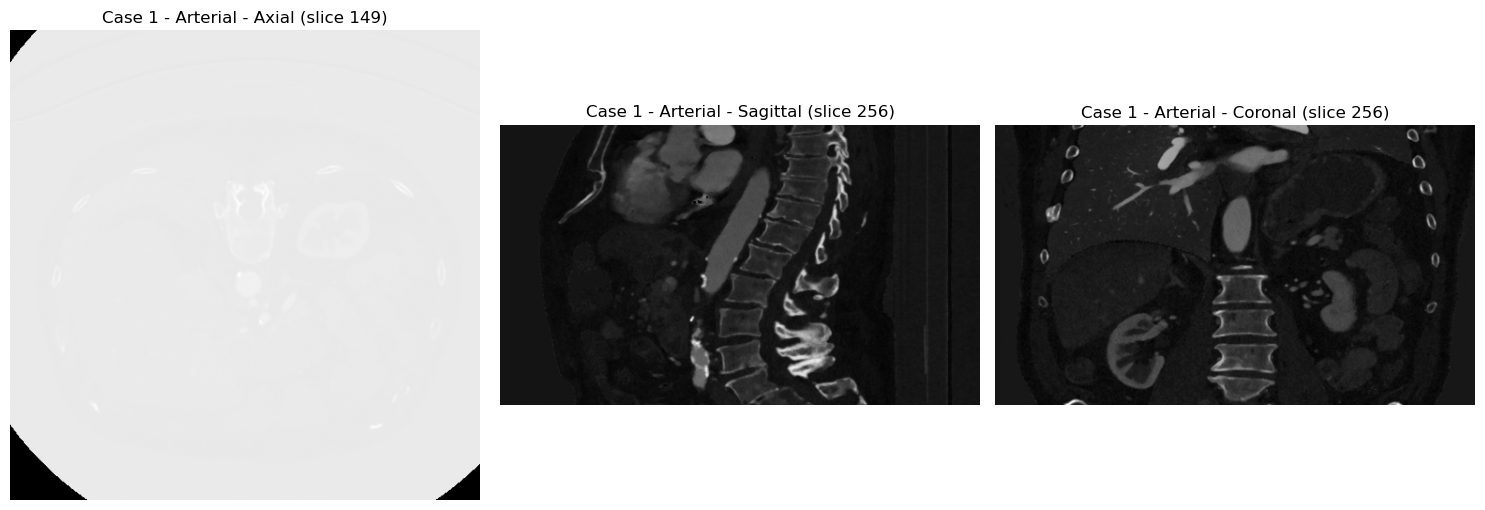

In [5]:
# Display middle slices in three orientations
def show_volume_slices(volume, title="Volume"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Axial slice (z-axis)
    z_slice = volume.shape[2] // 2
    axes[0].imshow(volume[:, :, z_slice].T, origin='lower')
    axes[0].set_title(f'{title} - Axial (slice {z_slice})')
    axes[0].axis('off')
    
    # Sagittal slice (x-axis)
    x_slice = volume.shape[0] // 2
    axes[1].imshow(volume[x_slice, :, :].T, origin='lower')
    axes[1].set_title(f'{title} - Sagittal (slice {x_slice})')
    axes[1].axis('off')
    
    # Coronal slice (y-axis)
    y_slice = volume.shape[1] // 2
    axes[2].imshow(volume[:, y_slice, :].T, origin='lower')
    axes[2].set_title(f'{title} - Coronal (slice {y_slice})')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

show_volume_slices(volume_data, f"Case {case_number} - {phase.capitalize()}")


## 6. Visualize Segmentation Overlay


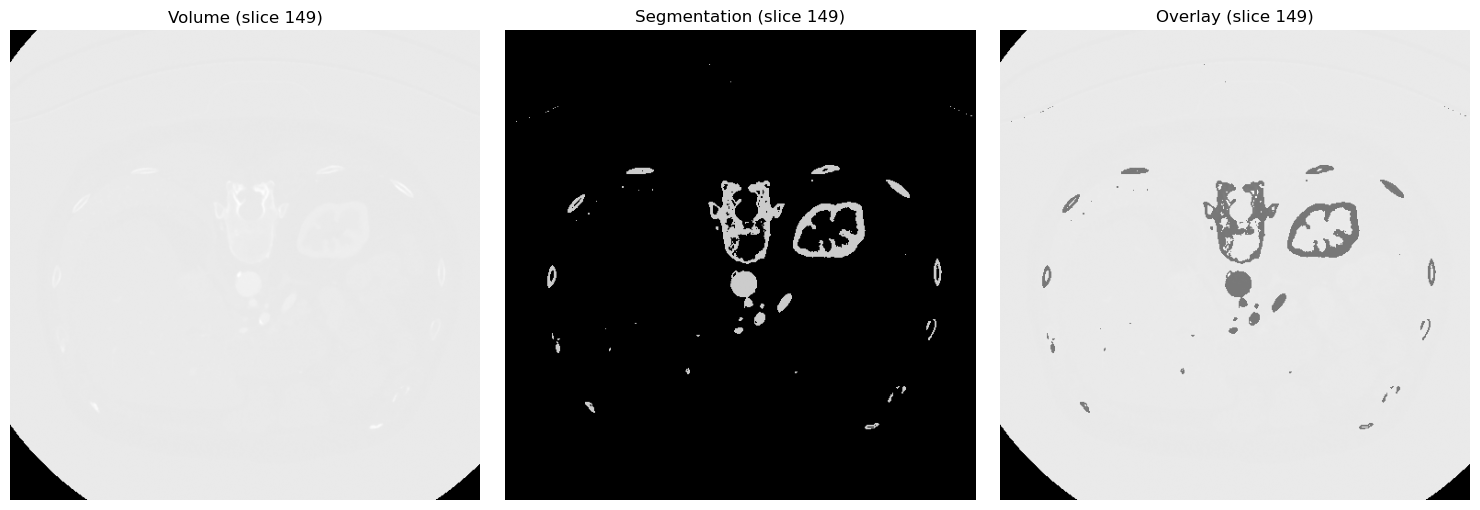

In [6]:
# Overlay segmentation on volume
def show_overlay(volume, segmentation, slice_idx=None):
    if slice_idx is None:
        slice_idx = volume.shape[2] // 2
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original volume
    vol_slice = volume[:, :, slice_idx].T
    axes[0].imshow(vol_slice, cmap='gray', origin='lower')
    axes[0].set_title(f'Volume (slice {slice_idx})')
    axes[0].axis('off')
    
    # Handle segmentation slice extraction
    # Check if segmentation has compatible dimensions
    if segmentation.shape[:2] == volume.shape[:2]:
        seg_slice = segmentation[:, :, slice_idx].T
    else:
        print(f"Warning: Segmentation shape {segmentation.shape} doesn't match volume shape {volume.shape}")
        seg_slice = segmentation[:, :, min(slice_idx, segmentation.shape[2]-1)].T
    
    # If seg_slice is somehow 2D with extra dimension, squeeze it
    if len(seg_slice.shape) > 2:
        seg_slice = seg_slice[:, :, 0] if seg_slice.shape[2] > 0 else seg_slice.squeeze()
    
    # Segmentation only
    axes[1].imshow(seg_slice, cmap='nipy_spectral', origin='lower')
    axes[1].set_title(f'Segmentation (slice {slice_idx})')
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(vol_slice, cmap='gray', origin='lower', alpha=1.0)
    # Create masked overlay (only show non-zero segmentation values)
    seg_mask = np.ma.masked_where(seg_slice == 0, seg_slice)
    axes[2].imshow(seg_mask, cmap='nipy_spectral', origin='lower', alpha=0.5)
    axes[2].set_title(f'Overlay (slice {slice_idx})')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show middle slice
show_overlay(volume_data, seg_data)


## 7. Interactive Slice Browser


In [7]:
# Browse through slices
from ipywidgets import interact, IntSlider

def browse_slices(slice_idx):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Volume
    vol_slice = volume_data[:, :, slice_idx].T
    axes[0].imshow(vol_slice, cmap='gray', origin='lower')
    axes[0].set_title(f'Volume - Slice {slice_idx}')
    axes[0].axis('off')
    
    # Handle segmentation slice extraction
    if seg_data.shape[:2] == volume_data.shape[:2]:
        seg_slice = seg_data[:, :, slice_idx].T
    else:
        seg_slice = seg_data[:, :, min(slice_idx, seg_data.shape[2]-1)].T
    
    # If seg_slice has extra dimensions, squeeze it
    if len(seg_slice.shape) > 2:
        seg_slice = seg_slice[:, :, 0] if seg_slice.shape[2] > 0 else seg_slice.squeeze()
    
    # Overlay
    axes[1].imshow(vol_slice, cmap='gray', origin='lower')
    seg_mask = np.ma.masked_where(seg_slice == 0, seg_slice)
    axes[1].imshow(seg_mask, cmap='nipy_spectral', origin='lower', alpha=0.5)
    axes[1].set_title(f'Overlay - Slice {slice_idx}')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Create interactive slider
interact(browse_slices, 
         slice_idx=IntSlider(min=0, max=volume_data.shape[2]-1, 
                             value=volume_data.shape[2]//2, 
                             description='Slice:'));


interactive(children=(IntSlider(value=149, description='Slice:', max=297), Output()), _dom_classes=('widget-in…

## 7b. Diagnose Segmentation Structure (Optional)


In [8]:
# Run this cell to understand your segmentation structure
print(f"Volume data shape: {volume_data.shape}")
print(f"Segmentation data shape: {seg_data.shape}")
print(f"Segmentation data type: {seg_data.dtype}")

# If segmentation has unusual dimensions, examine what's in each "layer"
if len(seg_data.shape) == 3 and seg_data.shape[2] <= 5:
    print(f"\nSegmentation appears to have only {seg_data.shape[2]} slices/layers")
    print("Examining each layer:")
    for i in range(seg_data.shape[2]):
        layer = seg_data[:, :, i]
        unique_vals = np.unique(layer)
        print(f"  Layer {i}: unique values = {unique_vals}, non-zero voxels = {np.sum(layer != 0)}")


Volume data shape: (512, 512, 298)
Segmentation data shape: (512, 512, 298)
Segmentation data type: uint8


## 8. Compare All Three Phases


arterial: 4D segmentation detected with 2 layers
  Combined to 3D: (512, 512, 298)
Loaded arterial: volume shape (512, 512, 298), segmentation shape (512, 512, 298)
venous: 4D segmentation detected with 3 layers
  Combined to 3D: (512, 512, 595)
Loaded venous: volume shape (512, 512, 595), segmentation shape (512, 512, 595)
late: 4D segmentation detected with 2 layers
  Combined to 3D: (512, 512, 223)
Loaded late: volume shape (512, 512, 223), segmentation shape (512, 512, 223)


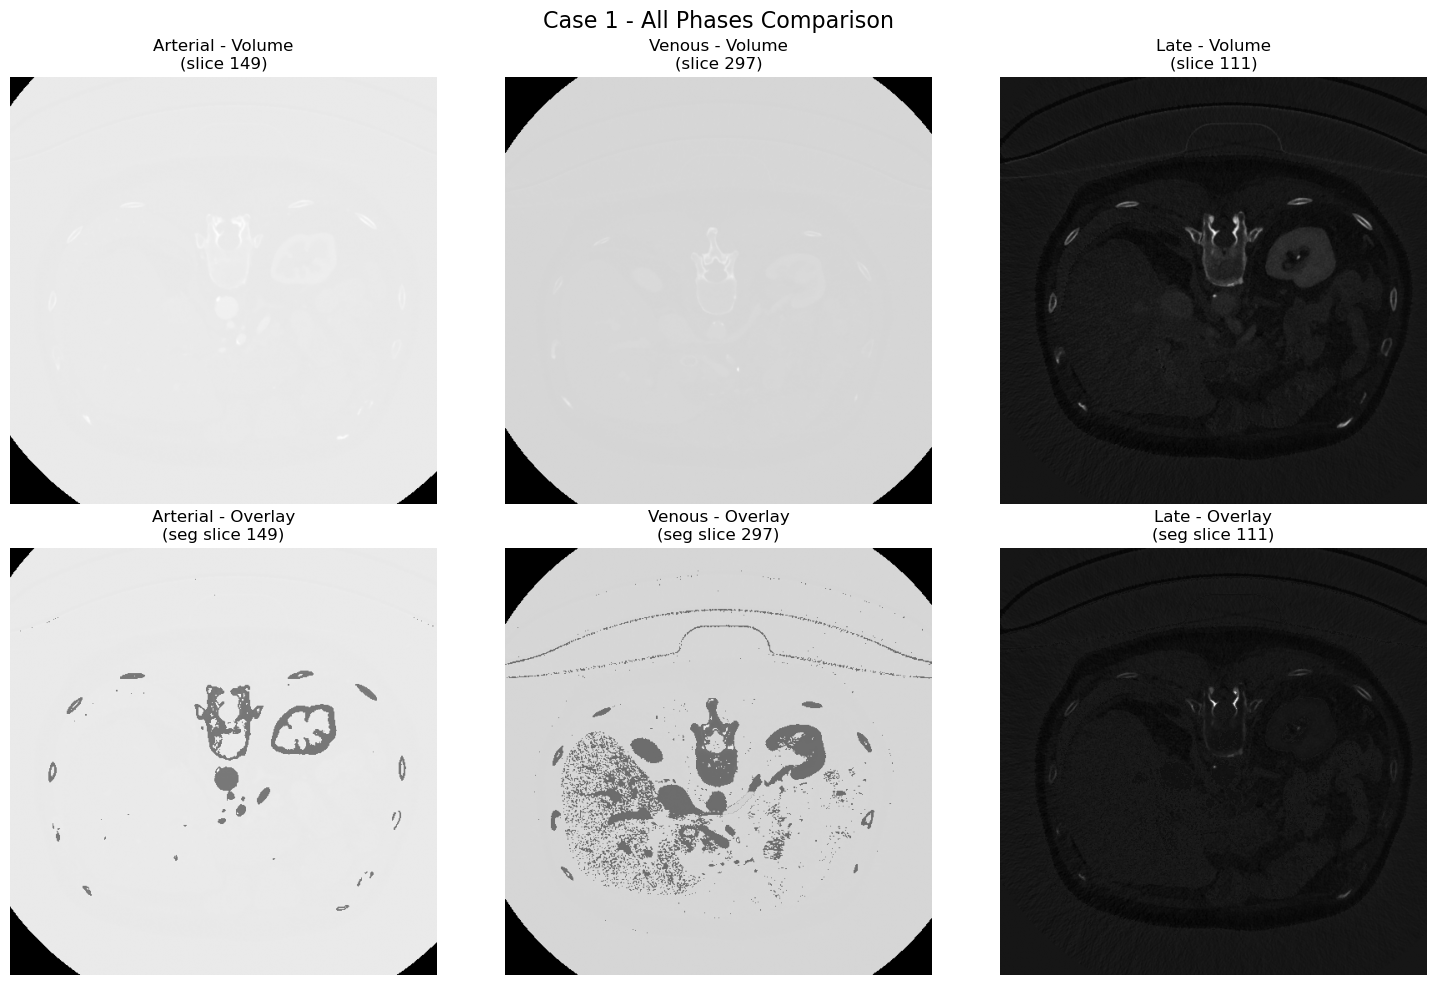

In [9]:
# Load all three phases for comparison
case = 1
phases = ['arterial', 'venous', 'late']

volumes = {}
segmentations = {}

for phase in phases:
    try:
        vol_path = f'Cases/{case}/Segmenteringer/volume_{phase}_{case}.nrrd'
        seg_path = f'Cases/{case}/Segmenteringer/segmentation_{phase}_{case}.seg.nrrd'
        
        vol, _ = nrrd.read(vol_path)
        seg, _ = nrrd.read(seg_path)
        
        # Handle 4D segmentations
        if len(seg.shape) == 4:
            print(f"{phase}: 4D segmentation detected with {seg.shape[0]} layers")
            # Combine layers into single 3D volume
            seg_3d = np.zeros(seg.shape[1:], dtype=seg.dtype)
            for i in range(seg.shape[0]):
                mask = seg[i, :, :, :] > 0
                seg_3d[mask] = i + 1
            seg = seg_3d
            print(f"  Combined to 3D: {seg.shape}")
        
        volumes[phase] = vol
        segmentations[phase] = seg
        print(f"Loaded {phase}: volume shape {vol.shape}, segmentation shape {seg.shape}")
    except FileNotFoundError as e:
        print(f"Could not find files for {phase} phase: {e}")

# Display all phases side by side
if volumes:  # Only plot if we have data
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    for idx, phase in enumerate(phases):
        if phase in volumes:
            vol = volumes[phase]
            seg = segmentations[phase]
            
            # Choose slice index based on volume dimensions
            vol_slice_idx = vol.shape[2] // 2
            
            # For segmentation, use a valid slice index
            seg_slice_idx = min(vol_slice_idx, seg.shape[2] - 1) if len(seg.shape) >= 3 else 0
            
            # Extract volume slice
            vol_slice = vol[:, :, vol_slice_idx].T
            axes[0, idx].imshow(vol_slice, cmap='gray', origin='lower')
            axes[0, idx].set_title(f'{phase.capitalize()} - Volume\n(slice {vol_slice_idx})')
            axes[0, idx].axis('off')
            
            # Extract segmentation slice carefully
            if len(seg.shape) == 3:
                seg_slice = seg[:, :, seg_slice_idx]
            elif len(seg.shape) == 2:
                seg_slice = seg
            else:
                print(f"Warning: Unexpected segmentation shape for {phase}: {seg.shape}")
                continue
            
            # Transpose to match volume orientation
            seg_slice = seg_slice.T
            
            # Ensure it's 2D
            if len(seg_slice.shape) > 2:
                seg_slice = seg_slice.squeeze()
            
            # Overlay
            axes[1, idx].imshow(vol_slice, cmap='gray', origin='lower')
            seg_mask = np.ma.masked_where(seg_slice == 0, seg_slice)
            axes[1, idx].imshow(seg_mask, cmap='nipy_spectral', origin='lower', alpha=0.5)
            axes[1, idx].set_title(f'{phase.capitalize()} - Overlay\n(seg slice {seg_slice_idx})')
            axes[1, idx].axis('off')

    plt.suptitle(f'Case {case} - All Phases Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No volumes loaded to display")


## 9a. Check All CSV Tables for a Case


In [10]:
# Check and display all CSV tables for the current case
import os

case_to_check = case_number
phases_to_check = ['arterial', 'venous', 'late']

print(f"Checking CSV tables for Case {case_to_check}:\n")

for phase in phases_to_check:
    table_path = f'Cases/{case_to_check}/Segmenteringer/table_{phase}_{case_to_check}.csv'
    
    if not os.path.exists(table_path):
        print(f"❌ {phase.capitalize()}: File not found")
    elif os.path.getsize(table_path) < 10:
        print(f"⚠️  {phase.capitalize()}: File is empty")
    else:
        try:
            df = pd.read_csv(table_path)
            print(f"✅ {phase.capitalize()}: {len(df)} rows, {len(df.columns)} columns")
            print(f"   Columns: {', '.join(df.columns[:5])}{'...' if len(df.columns) > 5 else ''}")
            display(df)
            print()
        except Exception as e:
            print(f"❌ {phase.capitalize()}: Error reading - {e}")
    print()


Checking CSV tables for Case 1:

✅ Arterial: 5 rows, 14 columns
   Columns: Segment, Voxel count (LM), Volume mm3 (LM), Volume cm3 (LM), Voxel count (SV)...


,Segment,Voxel count (LM),Volume mm3 (LM),Volume cm3 (LM),Voxel count (SV),Volume mm3 (SV),Volume cm3 (SV),Minimum,Maximum,Mean,Standard deviation,Percentile 5,Percentile 95,Median
0,arterial_threshold_1,2944174,1639820.000,1639.820000,2944174,1639820.000,1639.820000,89,576,194.116,98.3760,93,400,162
1,arterial_renal_artery_right_1,1408,784.215,0.784215,1408,784.215,0.784215,89,342,183.555,55.9712,95,263,186
2,arterial_renal_artery_left_1,1021,568.667,0.568667,1021,568.667,0.568667,89,258,174.652,46.3021,95,236,179
3,arterial_renal_vein_right_1,5025,2798.780,2.798780,5025,2798.780,2.798780,89,174,135.824,16.7380,99,156,139
4,arterial_renal_vein_left_1,3737,2081.400,2.081400,3737,2081.400,2.081400,89,212,121.047,16.1751,93,145,121




⚠️  Venous: File is empty

⚠️  Late: File is empty



## 9. Load and Display CSV Tables


In [11]:
# Read corresponding CSV table
table_path = f'Cases/{case_number}/Segmenteringer/table_{phase}_{case_number}.csv'

try:
    # Check if file exists and has content
    import os
    if not os.path.exists(table_path):
        print(f"Table file not found: {table_path}")
    elif os.path.getsize(table_path) == 0 or os.path.getsize(table_path) < 10:
        print(f"Table file is empty or too small: {table_path}")
    else:
        df = pd.read_csv(table_path)
        if df.empty:
            print(f"Table file contains no data: {table_path}")
        else:
            print(f"Table for Case {case_number} - {phase.capitalize()} phase:\n")
            display(df)
except pd.errors.EmptyDataError:
    print(f"Table file is empty or has no columns: {table_path}")
except Exception as e:
    print(f"Error reading table: {e}")


Table file is empty or too small: Cases/1/Segmenteringer/table_late_1.csv


## 10. Batch Processing - List All Available Cases


In [12]:
# Find all cases and available files
from pathlib import Path
import os

cases_dir = Path('Cases')
case_numbers = sorted([int(d.name) for d in cases_dir.iterdir() if d.is_dir() and d.name.isdigit()])

print(f"Found {len(case_numbers)} cases: {case_numbers}\n")

def check_file_status(file_path):
    """Check if file exists and has content"""
    if not file_path.exists():
        return '✗'  # File doesn't exist
    elif file_path.suffix == '.csv':
        # For CSV files, check if they have content
        if file_path.stat().st_size < 10:
            return '○'  # Empty file
        try:
            df = pd.read_csv(file_path)
            return '✓' if not df.empty else '○'  # Has data or empty
        except:
            return '○'  # Error reading or empty
    else:
        # For NRRD files, just check existence
        return '✓'

# Check what files exist for each case
inventory = []
for case in case_numbers:
    case_info = {'case': case}
    seg_dir = cases_dir / str(case) / 'Segmenteringer'
    
    for phase in ['arterial', 'venous', 'late']:
        vol_file = seg_dir / f'volume_{phase}_{case}.nrrd'
        seg_file = seg_dir / f'segmentation_{phase}_{case}.seg.nrrd'
        table_file = seg_dir / f'table_{phase}_{case}.csv'
        
        case_info[f'{phase}_volume'] = check_file_status(vol_file)
        case_info[f'{phase}_seg'] = check_file_status(seg_file)
        case_info[f'{phase}_table'] = check_file_status(table_file)
    
    inventory.append(case_info)

df_inventory = pd.DataFrame(inventory)
print("File availability by case:")
print("Legend: ✓ = exists with data, ○ = exists but empty, ✗ = missing\n")
display(df_inventory)


Found 25 cases: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

File availability by case:
Legend: ✓ = exists with data, ○ = exists but empty, ✗ = missing



,case,arterial_volume,arterial_seg,arterial_table,venous_volume,venous_seg,venous_table,late_volume,late_seg,late_table
0,1,✓,✓,✓,✓,✓,○,✓,✓,○
1,2,✓,✓,✓,✓,✓,✓,✓,✓,✓
2,3,✓,✓,✓,✓,✓,✓,✓,✓,✓
3,4,✓,✗,○,✓,✓,✓,✗,✓,✓
4,5,✓,✓,✓,✓,✓,✓,✓,✓,✓
5,6,✓,✓,✗,✓,✓,✓,✓,✓,✗
6,7,✓,✓,✓,✓,✓,✓,✓,✓,✓
7,8,✓,✓,○,✓,✓,✓,✓,✓,✓
8,9,✓,✓,✓,✓,✓,✓,✓,✓,✓
9,10,✓,✓,✓,✓,✓,✓,✓,✓,✓


## 11. Calculate Basic Statistics

In [13]:
# Calculate statistics from volume and segmentation
def calculate_stats(volume, segmentation, spacing=None):
    """
    Calculate basic statistics for segmented regions
    """
    # Check if volume and segmentation shapes match
    if volume.shape != segmentation.shape:
        print(f"Warning: Volume shape {volume.shape} doesn't match segmentation shape {segmentation.shape}")
        print("Statistics calculation requires matching dimensions.")
        print("This segmentation may only cover specific slices or have a different structure.")
        return pd.DataFrame()
    
    stats = []
    labels = np.unique(segmentation)
    labels = labels[labels != 0]  # Exclude background
    
    if len(labels) == 0:
        print("No segmentation labels found (all zeros)")
        return pd.DataFrame()
    
    for label in labels:
        mask = segmentation == label
        voxels = np.sum(mask)
        
        # Volume calculation (if spacing provided)
        if spacing is not None:
            voxel_volume = np.prod(spacing)
            volume_mm3 = voxels * voxel_volume
            volume_ml = volume_mm3 / 1000
        else:
            volume_ml = None
        
        # Intensity statistics
        intensities = volume[mask]
        
        stats.append({
            'label': label,
            'voxel_count': voxels,
            'volume_ml': volume_ml,
            'mean_intensity': intensities.mean(),
            'std_intensity': intensities.std(),
            'min_intensity': intensities.min(),
            'max_intensity': intensities.max()
        })
    
    return pd.DataFrame(stats)

# Get spacing from header if available
spacing = None
try:
    space_directions = volume_header.get('space directions', None)
    if space_directions is not None:
        # Handle different formats of space directions
        if isinstance(space_directions, np.ndarray):
            # Extract diagonal elements (spacing for each dimension)
            if len(space_directions.shape) == 2:
                # Standard case: extract norm of each row vector
                spacing = np.array([np.linalg.norm(space_directions[i]) for i in range(min(3, space_directions.shape[0]))])
            elif len(space_directions.shape) == 1:
                # Already a 1D array
                spacing = np.abs(space_directions[:3])
        print(f"Voxel spacing: {spacing} mm")
    else:
        # Try alternative spacing fields
        if 'spacings' in volume_header:
            spacing = np.array(volume_header['spacings'][:3])
            print(f"Voxel spacing (from 'spacings'): {spacing} mm")
        elif 'space' in volume_header:
            print(f"Space: {volume_header['space']}")
            print("Could not extract voxel spacing - volume calculations will be in voxels")
        else:
            print("No spacing information found in header - volume calculations will be in voxels")
except Exception as e:
    print(f"Error extracting spacing: {e}")
    print("Proceeding without spacing information")
    spacing = None

print()
print(f"Volume shape: {volume_data.shape}")
print(f"Segmentation shape: {seg_data.shape}")
print()

stats_df = calculate_stats(volume_data, seg_data, spacing)
if not stats_df.empty:
    print(f"Statistics for Case {case_number} - {phase.capitalize()} phase:")
    display(stats_df)
else:
    print("Could not calculate statistics due to shape mismatch.")
    print("\nNote: The segmentation file appears to have a different structure than the volume.")
    print("This is common when segmentations are saved in a different format or only cover specific regions.")
    print("You may want to use the CSV tables that were exported from 3D Slicer instead.")


Voxel spacing: [0.74630469 0.74630469 1.        ] mm

Volume shape: (512, 512, 298)
Segmentation shape: (512, 512, 298)

Statistics for Case 1 - Late phase:


,label,voxel_count,volume_ml,mean_intensity,std_intensity,min_intensity,max_intensity
0,1,2932983,1633.585555,194.321089,98.482705,89,576
1,2,11191,6.233059,140.437137,35.752082,89,342
